# 04 - B&B nodes analysis

Input:

- `analysis_output/preprocessed_core_data.csv`

Outputs:

- `analysis_output/bab_nodes_analysis.csv`
- `analysis_output/bab_nodes_vs_processes.png`
- `analysis_output/bab_nodes_per_second.png`
- `analysis_output/time_per_bab_node.png`

This notebook focuses on evaluated branch-and-bound nodes.

This is useful because a parallel search program can change the amount of search work. If runtime improves but evaluated nodes also change, speedup alone is not the full explanation.


In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

def read_rank_eval_data(filename):
    with open(filename, "r") as f:
        data = json.load(f)

    times = data["meta_data"]["node_eval_times"]
    counts = data["meta_data"]["node_eval_per_rank"]

    rows = []

    for rank, (time_s, node_count) in enumerate(zip(times, counts)):
        if rank == 0:
            continue
        rows.append({
            "rank": rank,
            "node_eval_time_s": time_s,
            "node_evals": node_count,
            "evals_per_second": node_count / time_s if time_s > 0 else None,
            "seconds_per_eval": time_s / node_count if node_count > 0 else None,
        })

    return pd.DataFrame(rows)

In [11]:
dfs = []
for file in glob('newest_solutions/*'):
    df_rank = read_rank_eval_data(file)
    dfs.append(df_rank)
display(dfs[0])


,rank,node_eval_time_s,node_evals,evals_per_second,seconds_per_eval
0,1,23.801627,67,2.814934,0.355248
1,2,23.543657,66,2.803303,0.356722
2,3,23.817861,67,2.813015,0.355490
3,4,24.079752,43,1.785733,0.559994
4,5,23.610604,59,2.498877,0.400180
...,...,...,...,...,...
506,507,15.056158,37,2.457466,0.406923
507,508,14.131103,32,2.264508,0.441597
508,509,13.623690,49,3.596676,0.278034
509,510,13.388985,44,3.286283,0.304295


In [ ]:
def plot_rank_node_evals(df_rank):
    plt.figure(figsize=(9, 5))
    plt.bar(df_rank["rank"], df_rank["node_evals"])
    plt.xlabel("Rank / core")
    plt.ylabel("Node evaluations")
    plt.title(f"Node evaluations per rank {len(df_rank)}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'babnodes_per_rank_{len(df_rank)}.png')
    plt.show()
    
def plot_rank_eval_times(df_rank):
    plt.figure(figsize=(9, 5))
    plt.bar(df_rank["rank"], df_rank["node_eval_time_s"])
    plt.xlabel("Rank / core")
    plt.ylabel("Node evaluation time [s]")
    plt.title(f"Node evaluation time per rank {len(df_rank)}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'compute_per_rank_{len(df_rank)}.png')
    plt.show()

def plot_rank_eval_throughput(df_rank):
    plt.figure(figsize=(9, 5))
    plt.bar(df_rank["rank"], df_rank["evals_per_second"])
    plt.xlabel("Rank / core")
    plt.ylabel("Node evaluations / second")
    plt.title(f"Node evaluation throughput per rank {len(df_rank)}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'throughput_per_rank_{len(df_rank)}.png')
    plt.show()

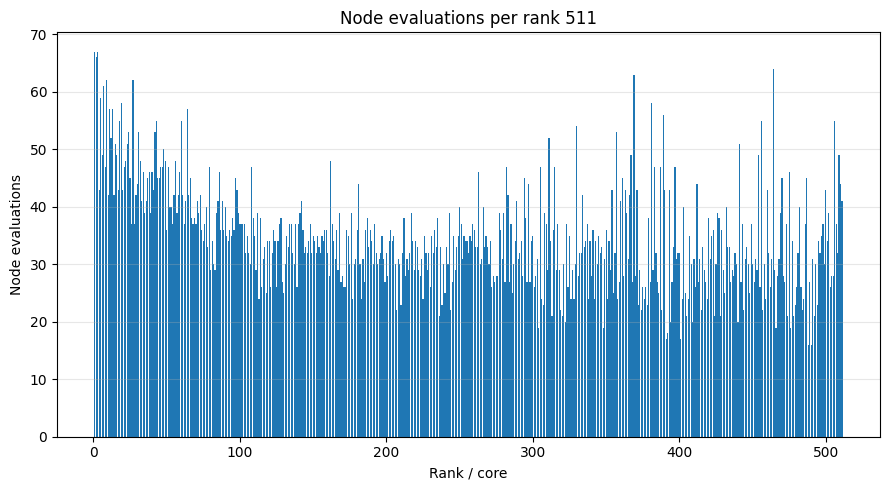

<Figure size 640x480 with 0 Axes>

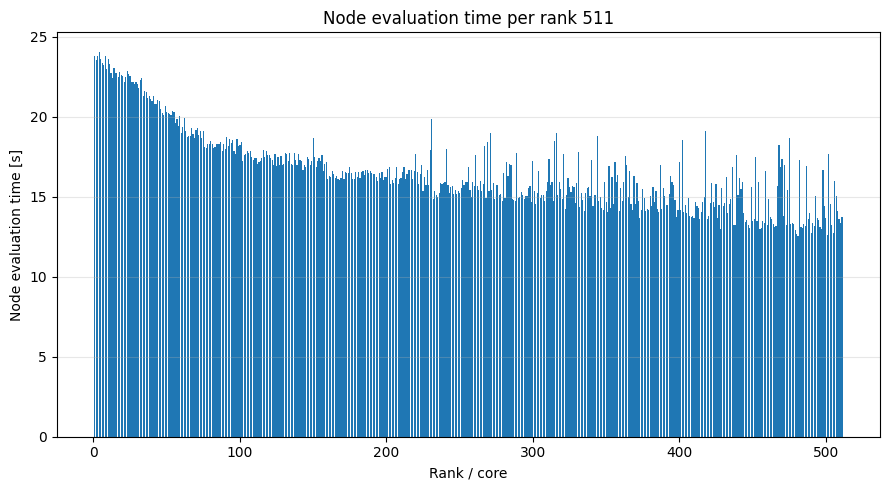

<Figure size 640x480 with 0 Axes>

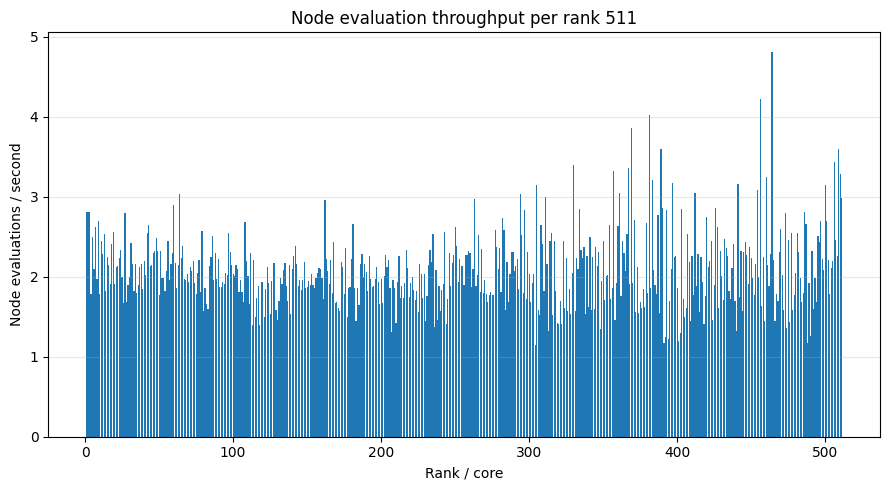

<Figure size 640x480 with 0 Axes>

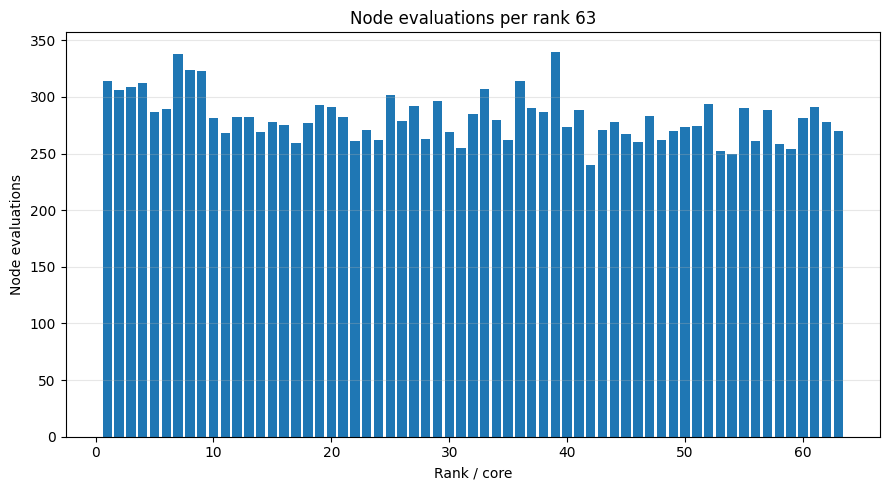

<Figure size 640x480 with 0 Axes>

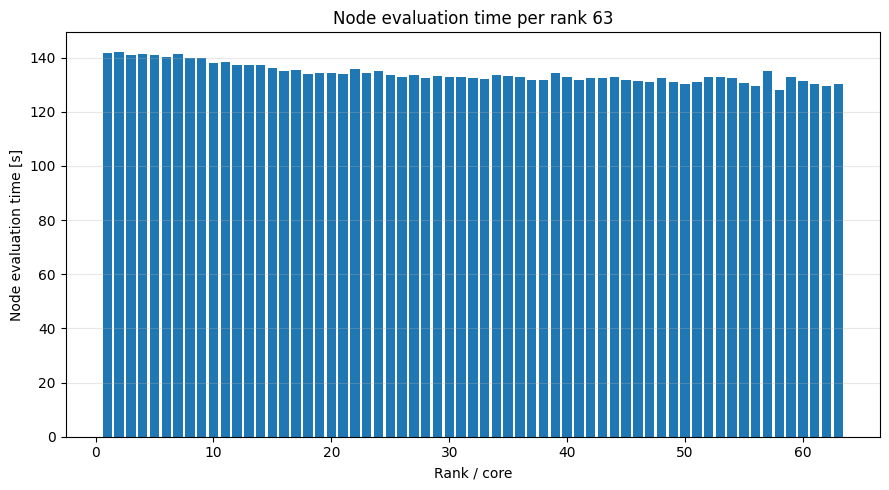

<Figure size 640x480 with 0 Axes>

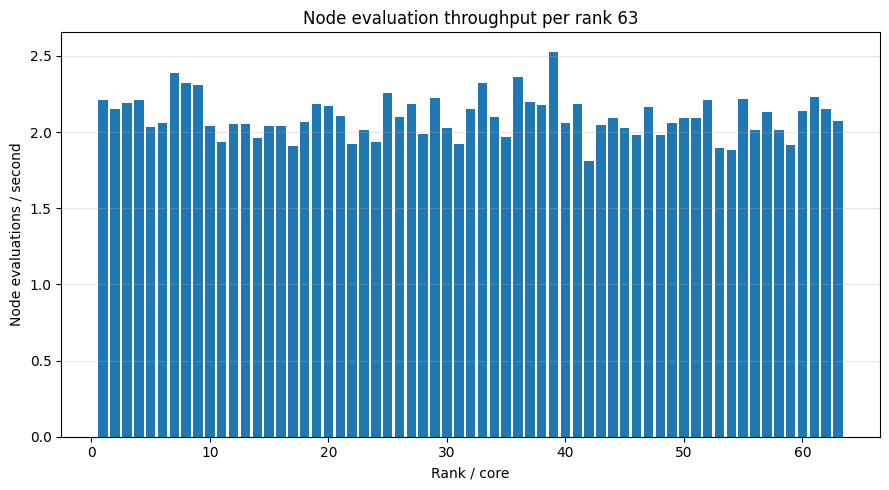

<Figure size 640x480 with 0 Axes>

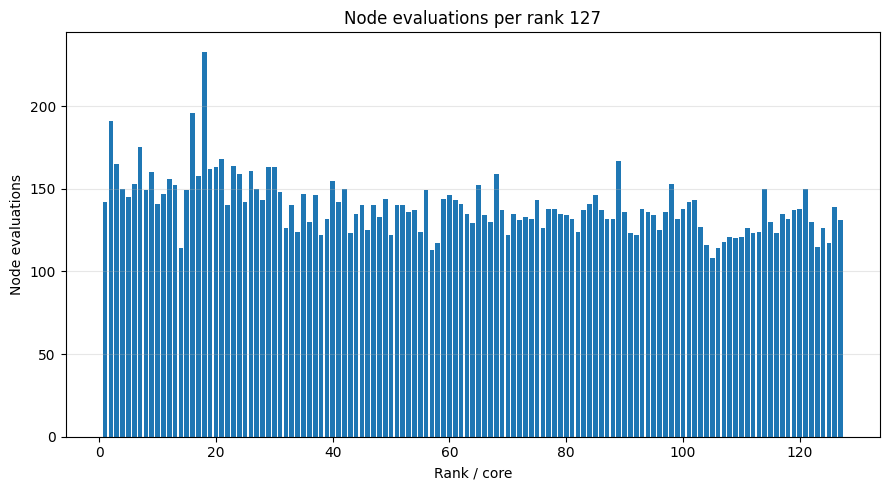

<Figure size 640x480 with 0 Axes>

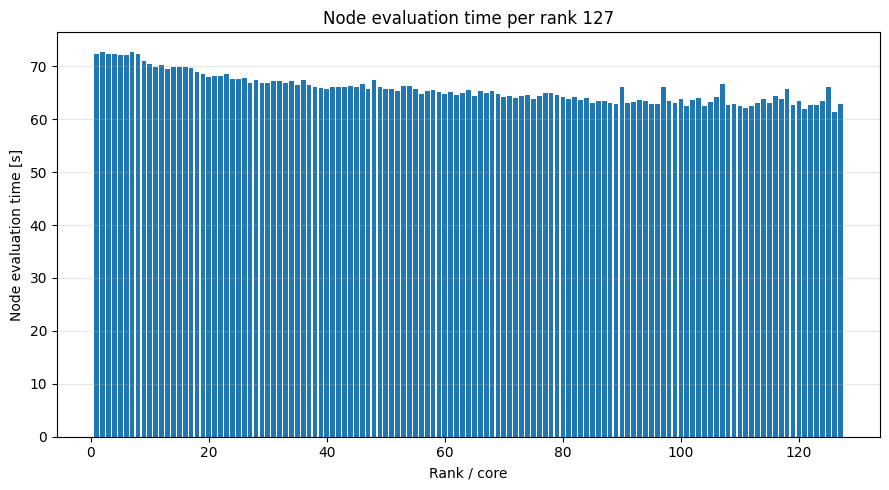

<Figure size 640x480 with 0 Axes>

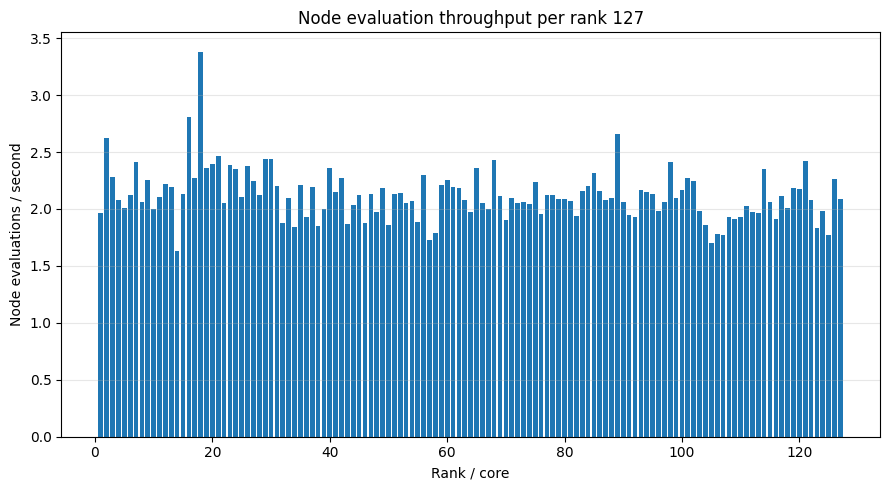

<Figure size 640x480 with 0 Axes>

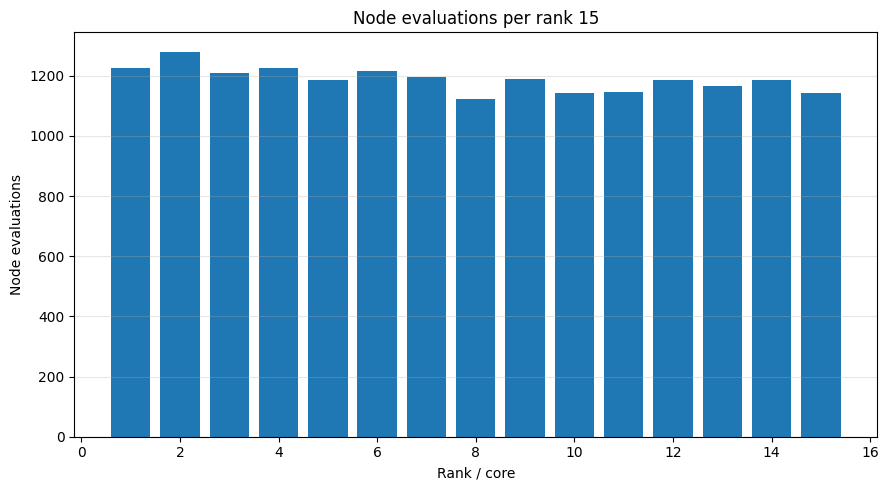

<Figure size 640x480 with 0 Axes>

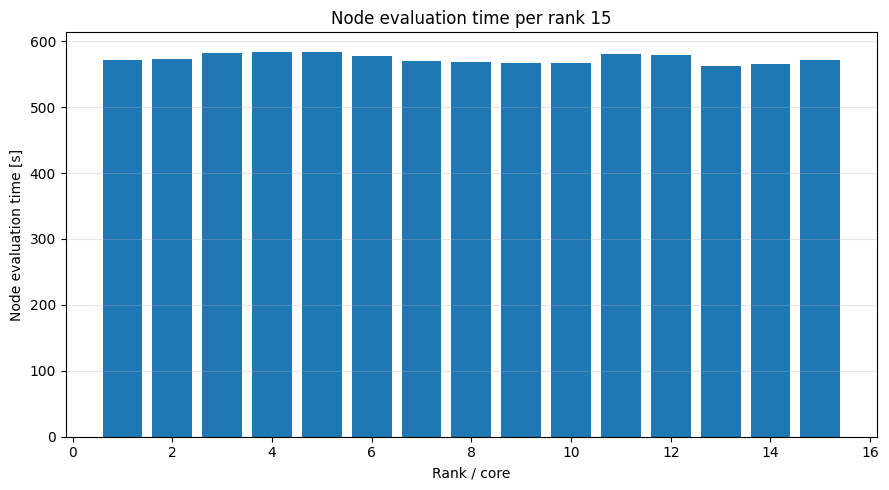

<Figure size 640x480 with 0 Axes>

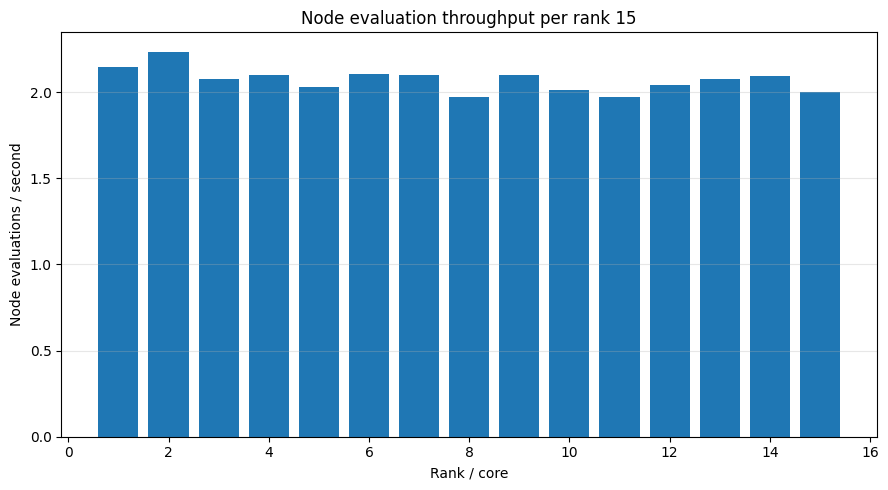

<Figure size 640x480 with 0 Axes>

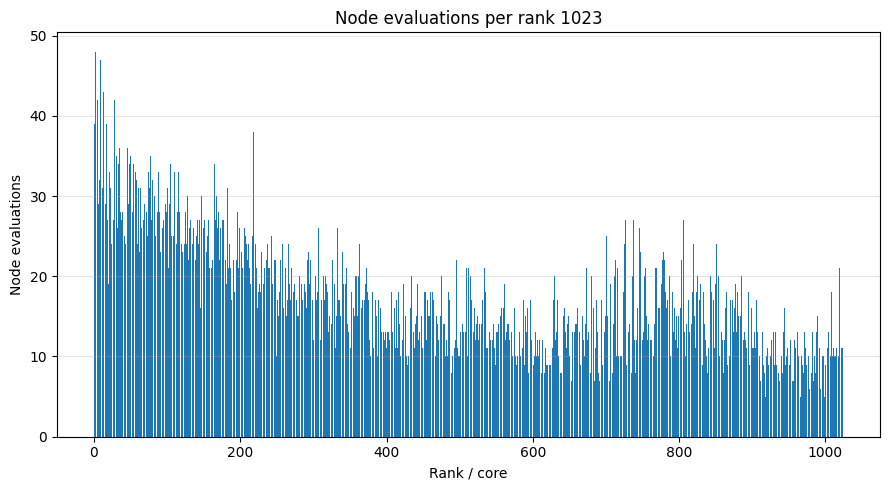

<Figure size 640x480 with 0 Axes>

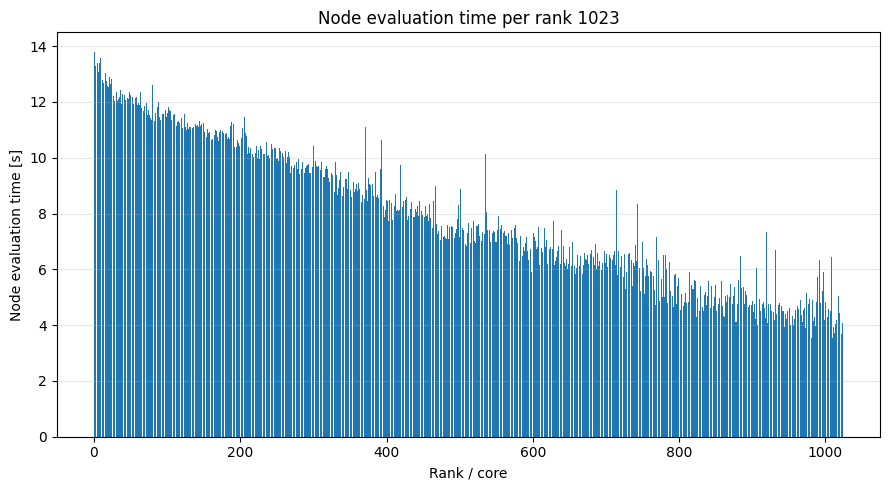

<Figure size 640x480 with 0 Axes>

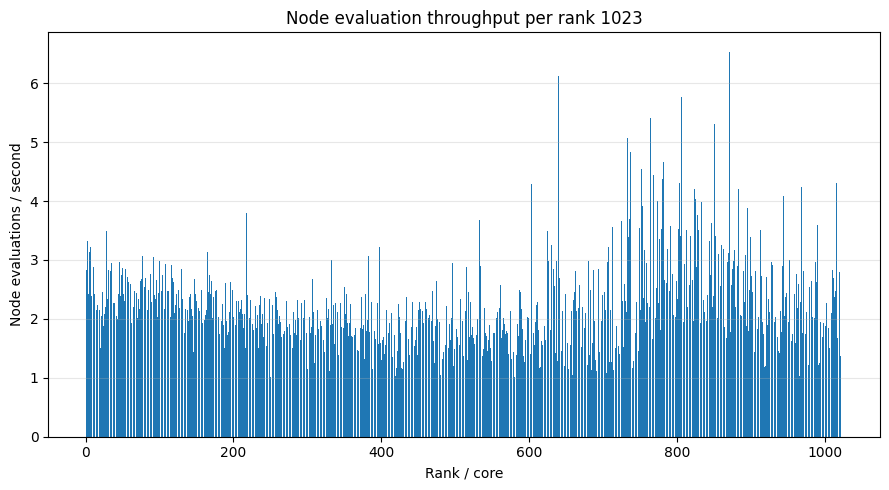

<Figure size 640x480 with 0 Axes>

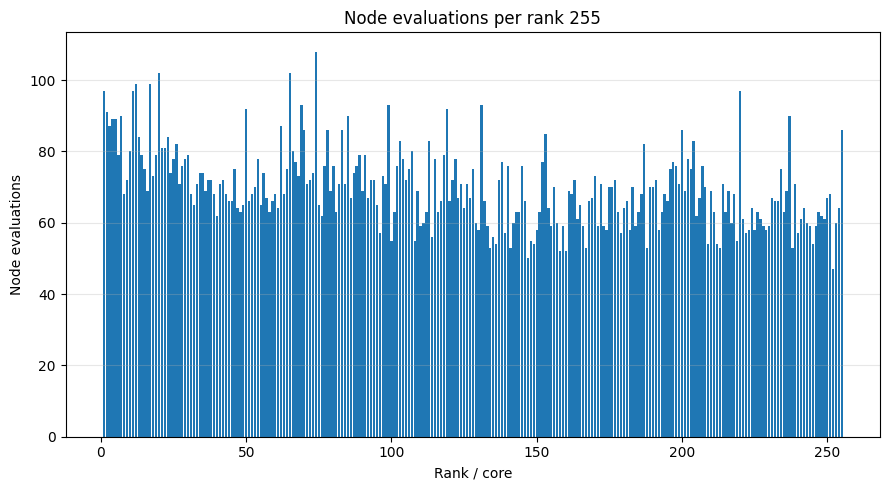

<Figure size 640x480 with 0 Axes>

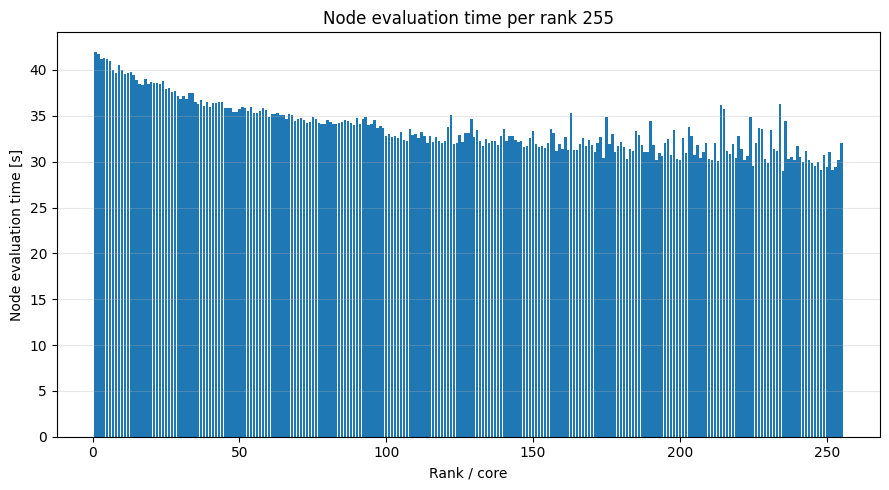

<Figure size 640x480 with 0 Axes>

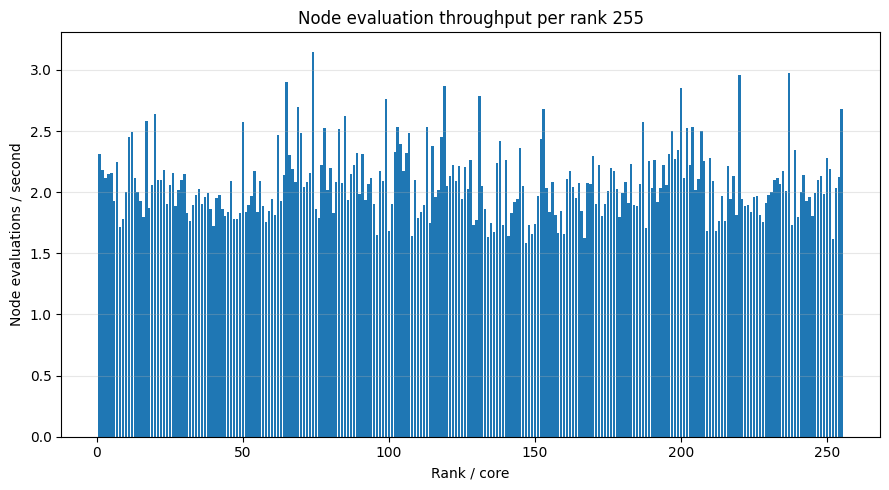

<Figure size 640x480 with 0 Axes>

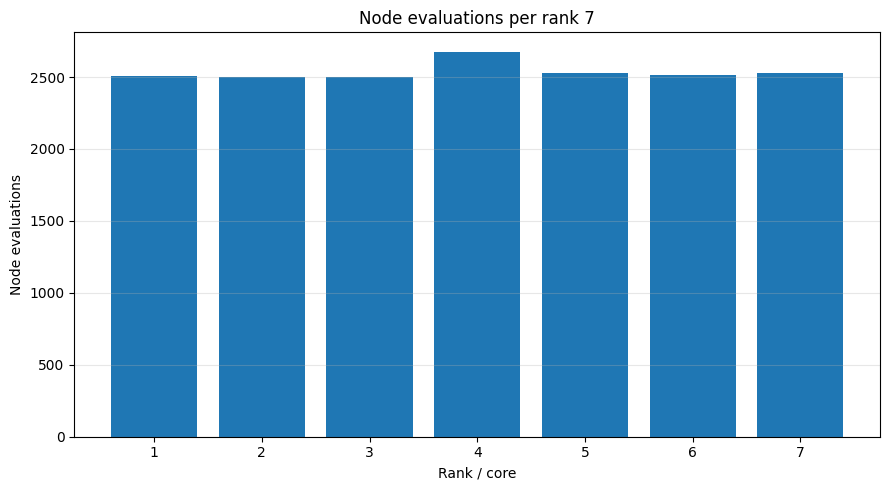

<Figure size 640x480 with 0 Axes>

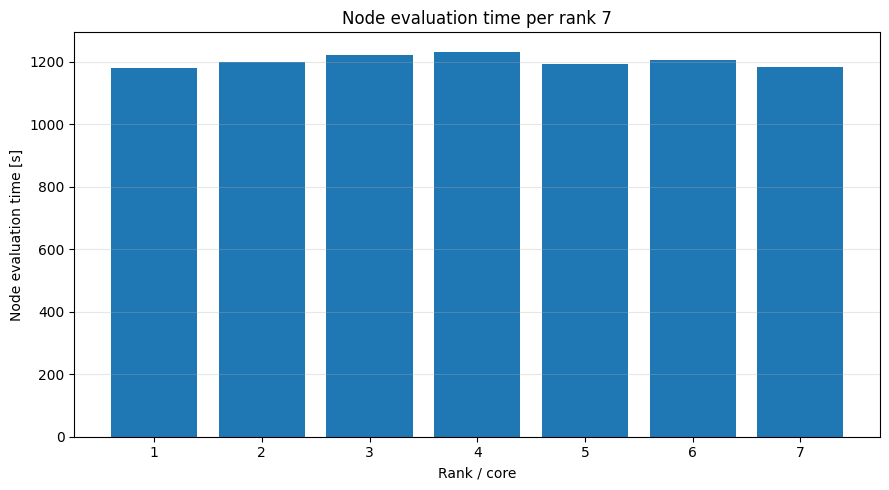

<Figure size 640x480 with 0 Axes>

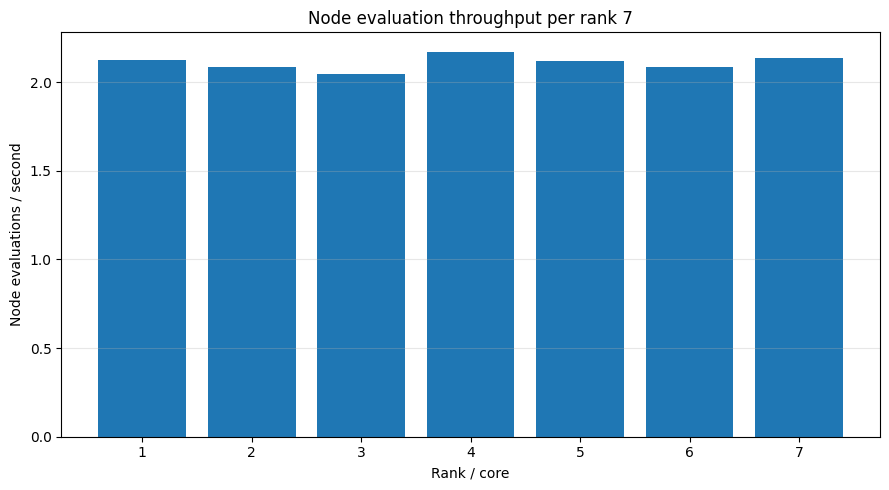

<Figure size 640x480 with 0 Axes>

In [15]:
for df_rank in dfs:
    plot_rank_node_evals(df_rank)
    plot_rank_eval_times(df_rank)
    plot_rank_eval_throughput(df_rank)
